In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [25]:
#read in data
df = pd.read_csv("tau_data.csv")
df['Actual Counts'] = df['Coincident Counts'] * 1000

In [ ]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [5]:
def step_model(x, center, width, steepness, amplitude, noise):
    x = np.array(x)
    y = amplitude * np.exp(-((np.abs(x - center) / width)**steepness)) + noise
    return y

In [8]:
def loss(theta):
    y_mod = step_model(df["Actual Tau?"], *theta)
    y_data = df["Actual Counts"]
    return np.sum((y_data - y_mod)**2/y_data)

In [26]:
opt_res = minimize(lambda p: loss(np.exp(p)), np.log(p0), method="Nelder-Mead")

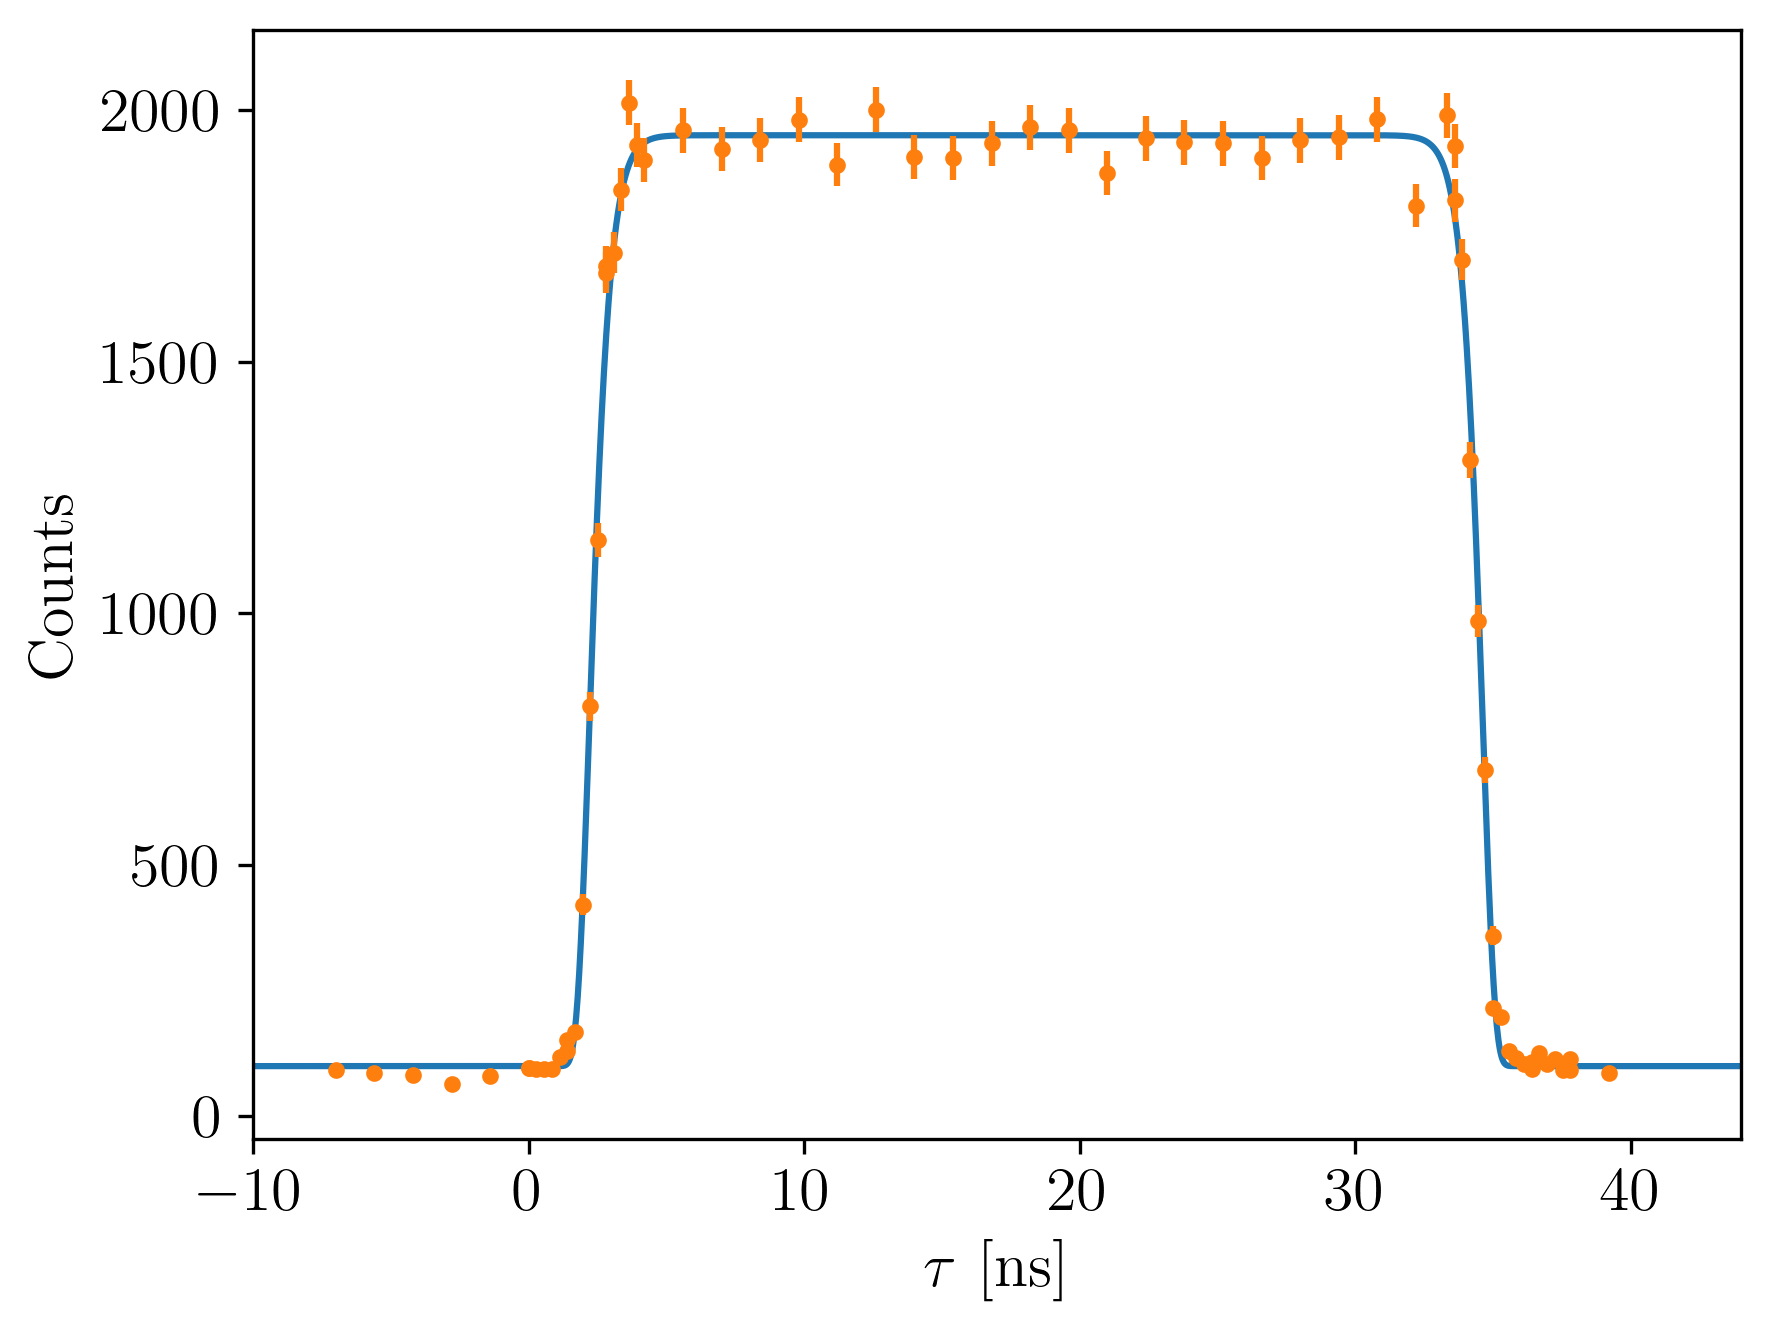

In [27]:
fig, ax = plt.subplots(dpi = 300)

x = np.linspace(-70, 70, 5000)
y = step_model(x, *np.exp(opt_res.x))
ax.plot(x, y)
ax.errorbar(df['Actual Tau?'], df['Actual Counts'], np.sqrt(df['Actual Counts']), ls="", marker = ".")
ax.set_xlabel("$\\tau$ [ns]")
ax.set_ylabel("Counts")
ax.set_xlim(-10, 44)
plt.savefig("tau_fit.png")

In [28]:
#mcmc prior
def log_prior(theta):
    if np.any(theta < 0):
        return -np.inf
    
    return 0

#mcmc log likelihood
def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    return -loss(theta)

In [29]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = np.exp(opt_res.x) + BUMP_SIZE * np.random.randn(N_WALKERS, len(opt_res.x))

In [30]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob)
sampler.run_mcmc(x0, 25_000, progress=True)

100%|██████████| 25000/25000 [01:27<00:00, 286.98it/s]


State([[  18.41632275   16.20035611   35.87977512 1853.63368664  101.70005829]
 [  18.41960752   16.2137774    37.42721118 1852.40210978   98.67905165]
 [  18.41822086   16.20618025   36.84034259 1844.31432602  101.78951527]
 [  18.4122727    16.2083203    37.04425695 1853.18586102   99.81251067]
 [  18.42176489   16.2093596    36.86082378 1845.71785996   98.76608436]
 [  18.41656769   16.20966571   37.2003443  1849.70462286   98.66711429]
 [  18.41331904   16.20640699   37.16856968 1849.70325942  101.99466205]
 [  18.40382811   16.2067025    35.83883144 1858.41946873   97.42528005]
 [  18.41412396   16.2126359    36.89315962 1851.13920238  100.34559908]
 [  18.41376491   16.21099852   36.83257978 1850.35514962  100.20664874]
 [  18.40904046   16.20655433   36.49707331 1852.335787    101.10949126]
 [  18.41716093   16.21932088   37.90876668 1858.14911139   96.62159341]
 [  18.41033219   16.20375769   36.45212127 1853.21896555   98.61698368]
 [  18.40389027   16.2149341    37.23828353 1

In [32]:
#names of parameters
param_labels = ["Center",
                "Width",
                "Steepness",
                "Amplitude",
                "Noise"]

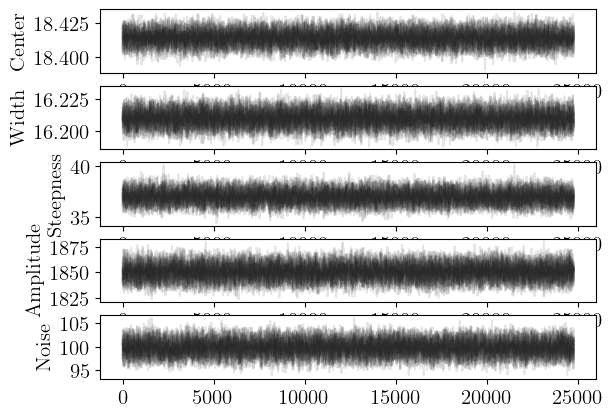

In [33]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

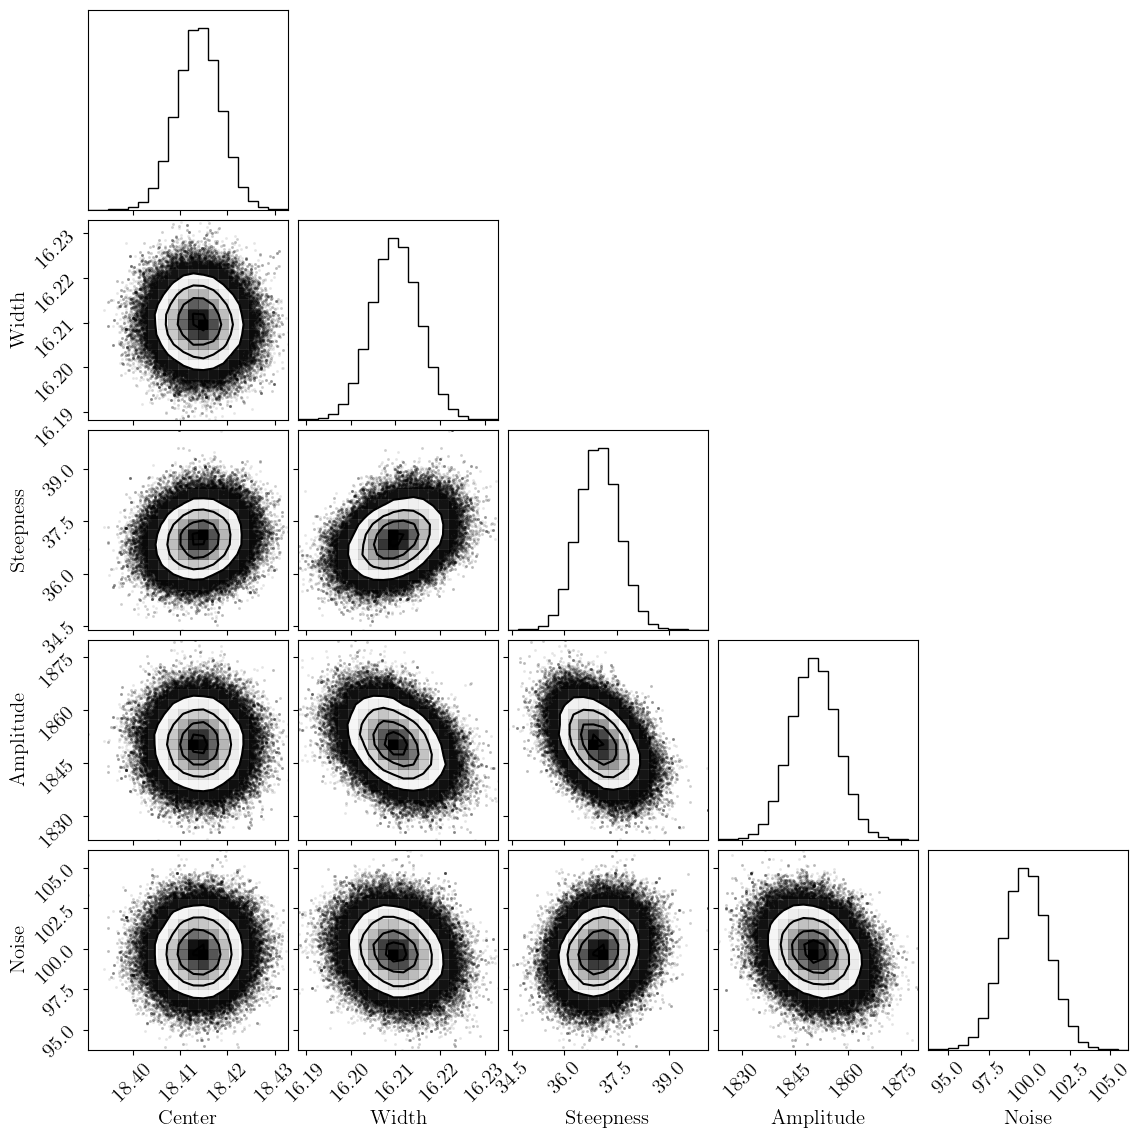

In [37]:
#examine posterior distributions of parameters
import corner
corner.corner(sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True), labels=param_labels);

In [46]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [47]:
results

,Median Value,2-sigma Uncertainty,Uncertainty/Value
Center,18.414022,0.009174,0.000498
Width,16.210120,0.010583,0.000653
Steepness,36.994857,1.154552,0.031208
Amplitude,1850.559293,12.991161,0.007020
Noise,99.810386,2.822951,0.028283
